# Sheetal Patil | Multiple Linear Regression

**Objective:** Task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.


**Business Understanding:**\
A large Toyota car dealership offers purchasers of new Toyota cars the option to buy their used car as part of a trade-in. In particular, a new promotion promises to pay high prices for used Toyota Corolla cars for purchasers of a new car. The dealer then sells the used car for a small profit. To ensure a reasonable profit, the dealer needs to be able to predict the price that the dealership will get for the used cars. For that reason, data were collected on all previous sales of used Toyota Corollas at the dealership. The data include the sales price and other information on the car, such as its age, mileage, fuel type, and engine size.

**Dataset Description:**\
The dataset consists of the following variables:

**Price:** Offer Price in EUROs\
**Age:** Age in years\
**KM:** Accumulated Kilometers on odometer\
**FuelType:** Fuel Type (Petrol, Diesel, CNG)\
**HP:** Horse Power\
**Automatic:** Automatic ( (Yes=1, No=0)\
**CC:** Cylinder Volume in cubic centimeters\
**Doors:** Number of doors\
**Cylinders:** Number of cylinders\
**Quarterly_Tax:** Quarterly road tax in EUROs\
**Gears:** Number of gear positions\
**Weight:** Weight in Kilograms

In [47]:
#import the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

In [48]:
# loading or reading the data
dataframe = pd.read_csv("D:\\Work\\ExcelRCource\\Assignments\\6 MLR\\ToyotaCorolla - MLR.csv")

In [49]:
# Printing the data
dataframe

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Quarterly_Tax,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,210,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,210,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,210,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,210,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,210,5,1170
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,69,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,69,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,69,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,69,5,1015


In [50]:
type(dataframe)

pandas.core.frame.DataFrame

In [51]:
dataframe.shape

(1436, 12)

In [52]:
# data types of each column
dataframe.dtypes

Price             int64
Age_08_04         int64
KM                int64
Fuel_Type        object
HP                int64
Automatic         int64
cc                int64
Doors             int64
Cylinders         int64
Quarterly_Tax     int64
Gears             int64
Weight            int64
dtype: object

Here all columns have same data type- int64, except column Fuel_Type. Its datatype is object.

In [53]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Price          1436 non-null   int64 
 1   Age_08_04      1436 non-null   int64 
 2   KM             1436 non-null   int64 
 3   Fuel_Type      1436 non-null   object
 4   HP             1436 non-null   int64 
 5   Automatic      1436 non-null   int64 
 6   cc             1436 non-null   int64 
 7   Doors          1436 non-null   int64 
 8   Cylinders      1436 non-null   int64 
 9   Quarterly_Tax  1436 non-null   int64 
 10  Gears          1436 non-null   int64 
 11  Weight         1436 non-null   int64 
dtypes: int64(11), object(1)
memory usage: 134.8+ KB


Here all columns are having 1436 non null values. Memory usage for this dataframe is 134.8+ KB.

### Data Cleaning

In [54]:
#The method .copy() is used here so that any changes made in new DataFrame don't get reflected in the original one
Data = dataframe.copy()

In [55]:
Data.isna().sum()

Price            0
Age_08_04        0
KM               0
Fuel_Type        0
HP               0
Automatic        0
cc               0
Doors            0
Cylinders        0
Quarterly_Tax    0
Gears            0
Weight           0
dtype: int64

Dataframe is consists of zero null values.

In [56]:
# No of unique values of each feature in dataset.
Data.nunique()

Price             236
Age_08_04          77
KM               1263
Fuel_Type           3
HP                 12
Automatic           2
cc                 13
Doors               4
Cylinders           1
Quarterly_Tax      13
Gears               4
Weight             59
dtype: int64

Here in this dataframe, we can see Cylinders column has only one unique value. So this column data will not be helpful for further analysis. 

In [57]:
#Removing the Cylinders column from the dataframe as its data is not needed.
data = Data[["Price","Age_08_04","KM","Fuel_Type","HP","Automatic","cc","Doors","Quarterly_Tax","Gears","Weight"]]
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Quarterly_Tax,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,210,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,210,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,210,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,210,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,210,5,1170


In [58]:
# finding any Duplicated data
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1431    False
1432    False
1433    False
1434    False
1435    False
Length: 1436, dtype: bool

In [59]:
#Count of duplicated rows
data[data.duplicated()].shape

(1, 11)

In [60]:
# Printing Duplicated data
data[data.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Quarterly_Tax,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,234,5,1320


In [61]:
#delete the duplicate row
data1= data.drop_duplicates()
#the duplicate row is seen deleted
data1.iloc[109:115]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Quarterly_Tax,Gears,Weight
109,32500,4,1,Diesel,116,0,2000,5,283,5,1480
110,31000,4,4000,Diesel,116,0,2000,5,283,5,1480
111,31275,4,1500,Diesel,116,0,2000,5,283,5,1480
112,24950,8,13253,Diesel,116,0,2000,5,234,5,1320
114,22950,7,10000,Diesel,116,0,2000,5,234,5,1270
115,24990,8,6000,Diesel,90,0,2000,5,234,5,1280


In [62]:
#reassign the row number by reset index
data1= data1.reset_index()
data1.iloc[108:115]

,index,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Quarterly_Tax,Gears,Weight
108,108,17950,20,7187,Petrol,110,0,1600,3,85,5,1105
109,109,32500,4,1,Diesel,116,0,2000,5,283,5,1480
110,110,31000,4,4000,Diesel,116,0,2000,5,283,5,1480
111,111,31275,4,1500,Diesel,116,0,2000,5,283,5,1480
112,112,24950,8,13253,Diesel,116,0,2000,5,234,5,1320
113,114,22950,7,10000,Diesel,116,0,2000,5,234,5,1270
114,115,24990,8,6000,Diesel,90,0,2000,5,234,5,1280


In [63]:
#Drop the original index
data1= data1.drop(['index'], axis=1)
data1

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Quarterly_Tax,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,210,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,210,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,210,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,210,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,210,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,Petrol,86,0,1300,3,69,5,1025
1431,10845,72,19000,Petrol,86,0,1300,3,69,5,1015
1432,8500,71,17016,Petrol,86,0,1300,3,69,5,1015
1433,7250,70,16916,Petrol,86,0,1300,3,69,5,1015


In [64]:
#renaming the column names
data2= data1.rename({'Age_08_04':'Age','Fuel_Type':'FT','cc':'CC','Quarterly_Tax':'QT'}, axis = 1)
data2.head()

,Price,Age,KM,FT,HP,Automatic,CC,Doors,QT,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,210,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,210,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,210,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,210,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,210,5,1170


### Statistical Analysis

In [65]:
# data analysis for numerical data
data2.describe()

,Price,Age,KM,HP,Automatic,CC,Doors,QT,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,87.020209,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,40.959588,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,19.000000,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,69.000000,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,85.000000,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,85.000000,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,283.000000,6.000000,1615.000000


Here Age column has max value 80, which seem to be unrealistic. Also in Price column, minimum value of car is 4350 which is again seem to be an unrealistic value for the car. Automatic column has two values 0(Manual) and 1(Automatic).

In [66]:
# data analysis for categorical data
data2.describe(include= object)

,FT
count,1435
unique,3
top,Petrol
freq,1264


Petrol is the most frequent value with count 1264 in Fuel Type column.

<Axes: xlabel='FT'>

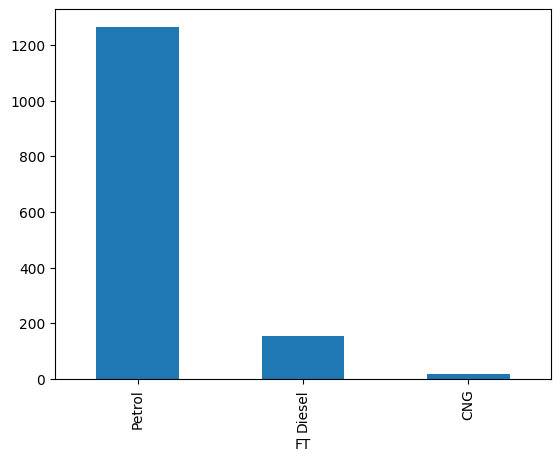

In [88]:
data2['FT'].value_counts().plot.bar()

**Class Imbalance:** The dataset is heavily skewed toward "Petrol" cases (1264), with "Diesel" (less than 200) and "CNG" (less than 50) being significantly less frequent.

### Outlier Detection

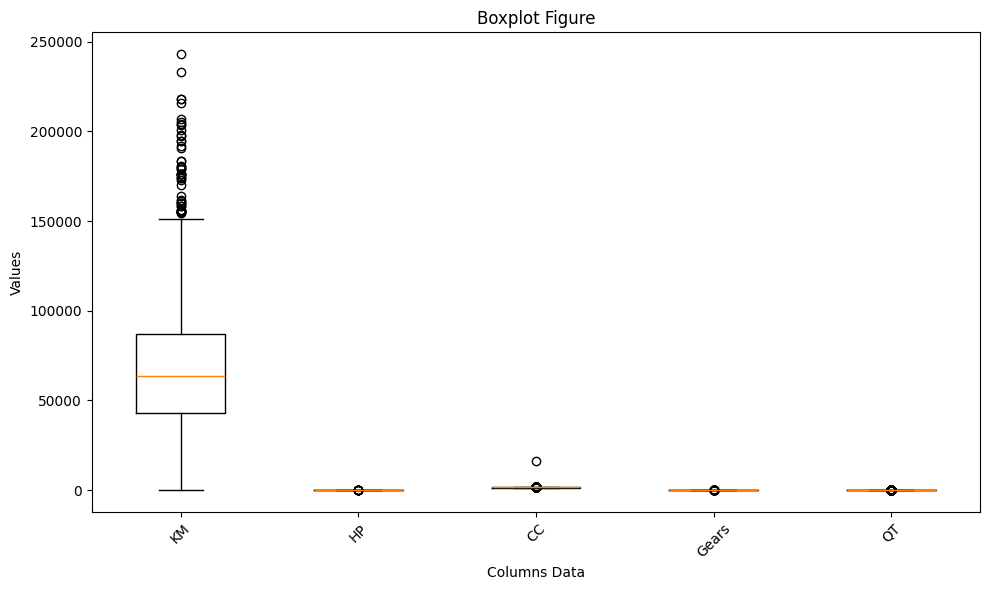

In [75]:
# Combine boxplot of dataset
data_to_plot = data2[['KM', 'HP', 'CC','Gears','QT']]

# Create multiple boxplots
plt.figure(figsize=(10, 6))
box_plot = plt.boxplot(data_to_plot, labels=['KM', 'HP', 'CC', 'Gears','QT'])
plt.title('Boxplot Figure')
plt.ylabel('Values')
plt.xlabel('Columns Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

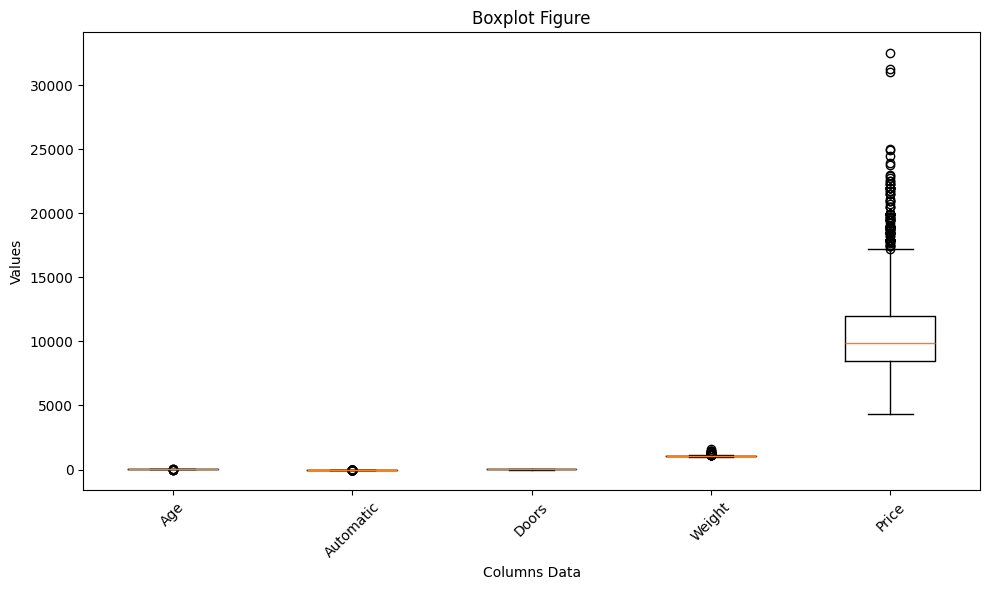

In [82]:
# Combine datasets
data_to_plot = data2[['Age', 'Automatic', 'Doors', 'Weight', 'Price']]

# Create multiple boxplots
plt.figure(figsize=(10, 6))
box_plot = plt.boxplot(data_to_plot, labels=['Age', 'Automatic', 'Doors', 'Weight','Price'])
plt.title('Boxplot Figure')
plt.ylabel('Values')
plt.xlabel('Columns Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Price and KM has many outliers.

### Data Visualization (EDA)

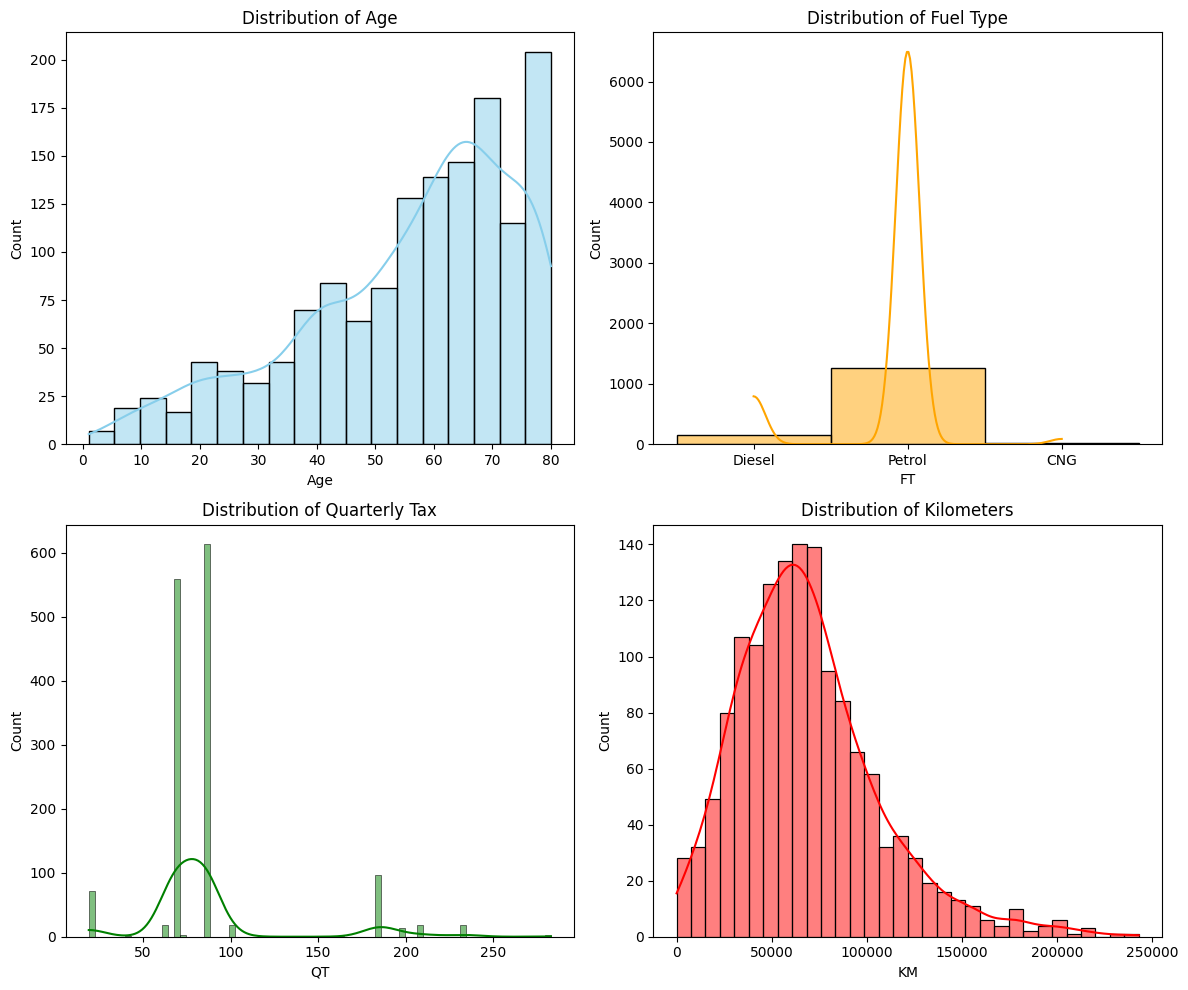

In [69]:
# 2. Histograms for selected features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data2['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Age')

sns.histplot(data2['FT'], kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribution of Fuel Type')

sns.histplot(data2['QT'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Quarterly Tax')

sns.histplot(data2['KM'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Distribution of Kilometers')

plt.tight_layout()
plt.show()

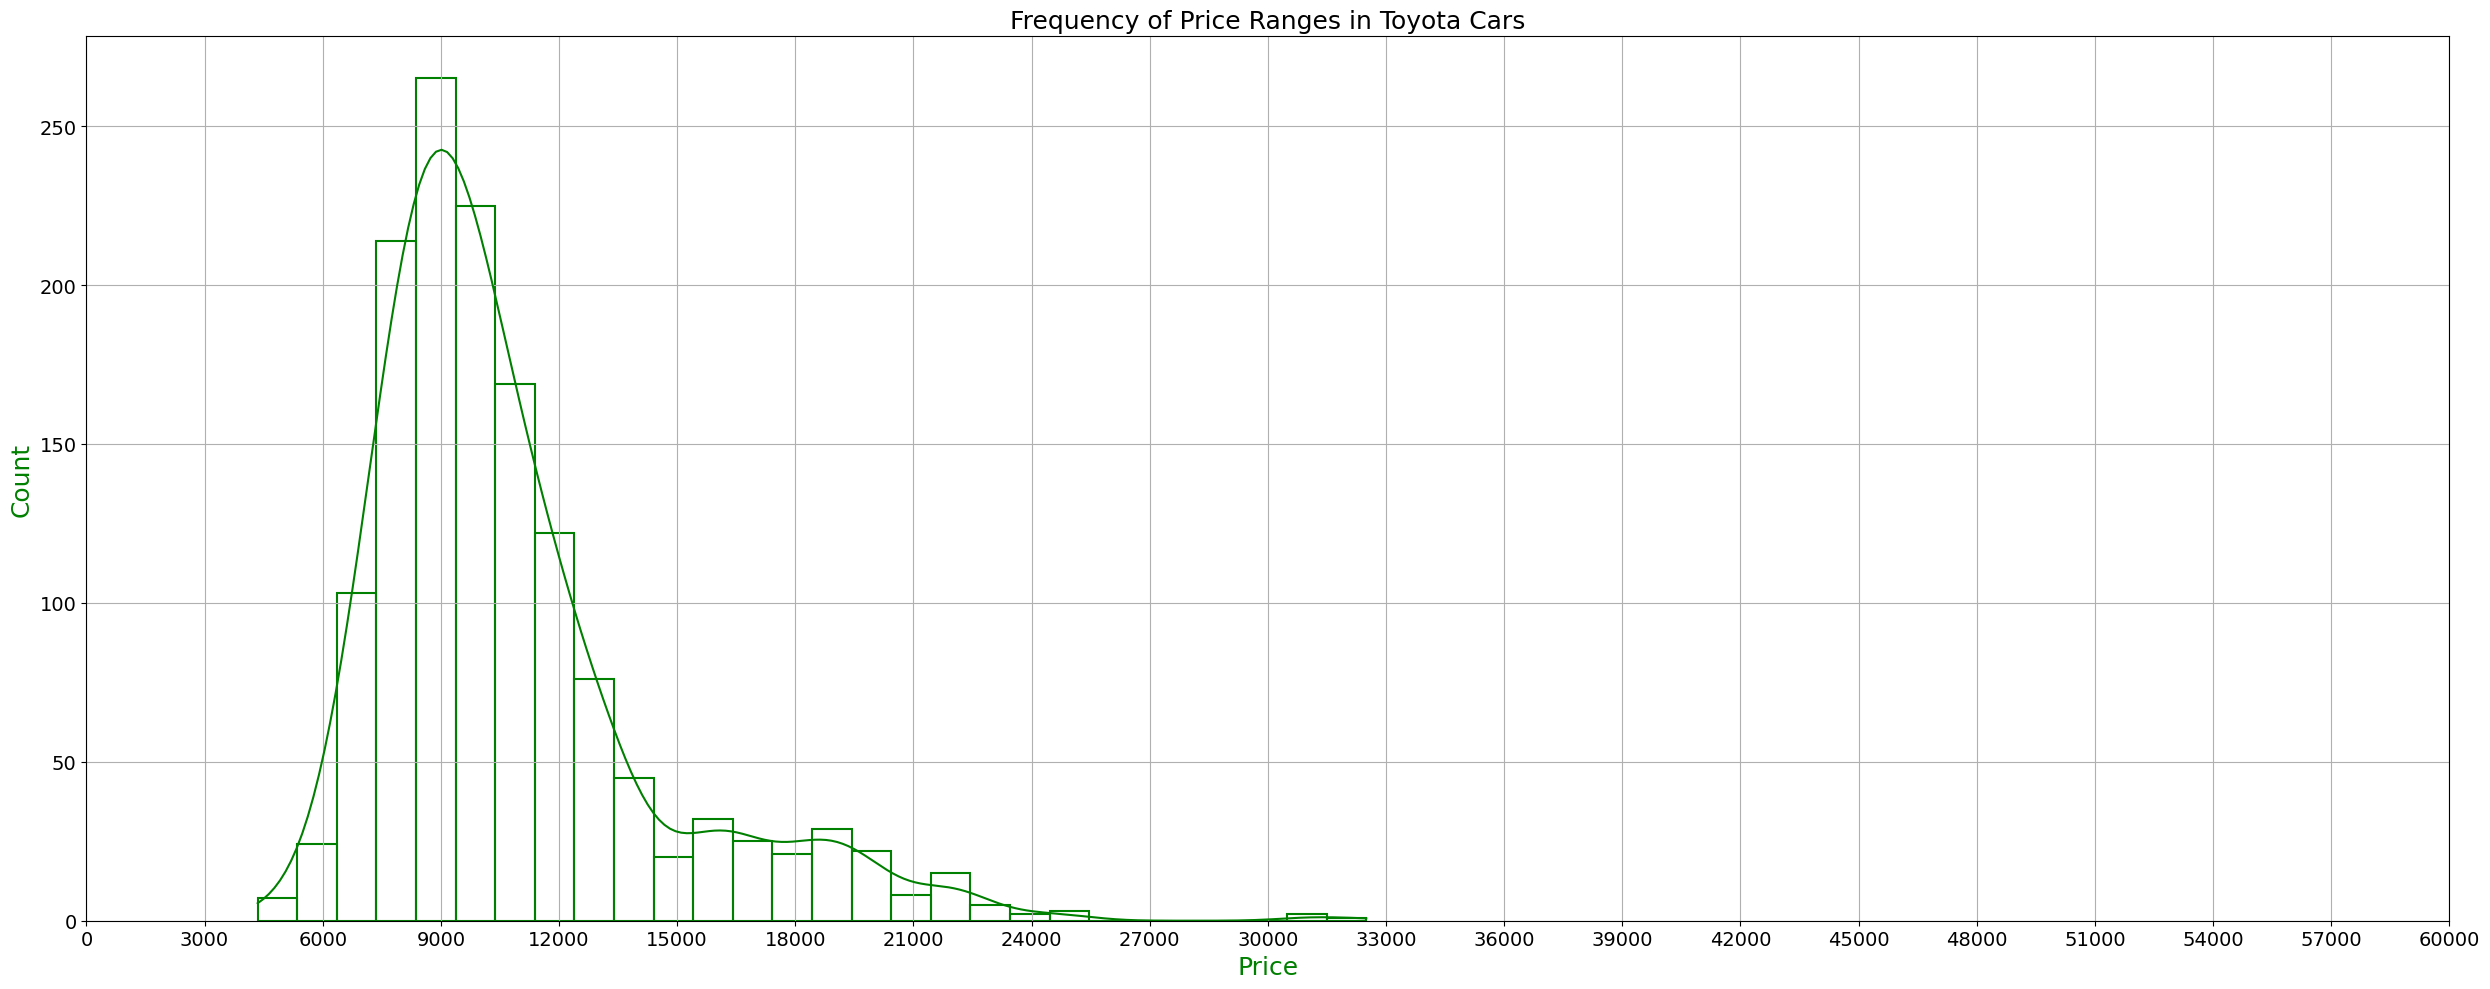

In [70]:
#Histogram
plt.figure(figsize=(25,10))
sns.histplot(x="Price", data=data2, binwidth=1000, kde=True, color="green", fill=False)
plt.title("Frequency of Price Ranges in Toyota Cars", fontsize=18)
plt.xticks(np.arange(0,60001,3000), fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Price", fontsize=18, color='green')
plt.ylabel("Count", fontsize=18, color='green')
plt.grid()
plt.tight_layout()
plt.show()

**Histograms:** The distribution of FT follows a near-normal bell curve, whereas Age, QT, KM and Price show multi-modal or skewed distributions.
Price - Most cars belong to the price range of 7,000-10,000, where the median value 9,000 also lies.

Text(0, 0.5, 'Price')

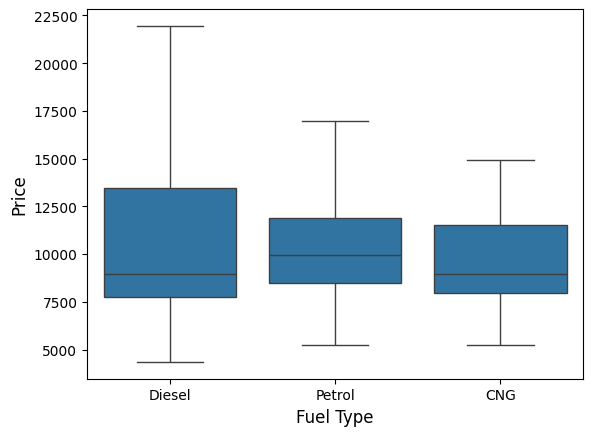

In [97]:
sns.boxplot(y = "Price", data=data2, showfliers=False, x="FT")
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Price", fontsize=12)

**Boxplot Observations**
Even though the price range of "Other" is much wider than "Petrol", their medians are very close (9000-10000).\
Toyota models running on Petrol are the most affordable. Cars running on Hybrid fuel come in the most versatile price range

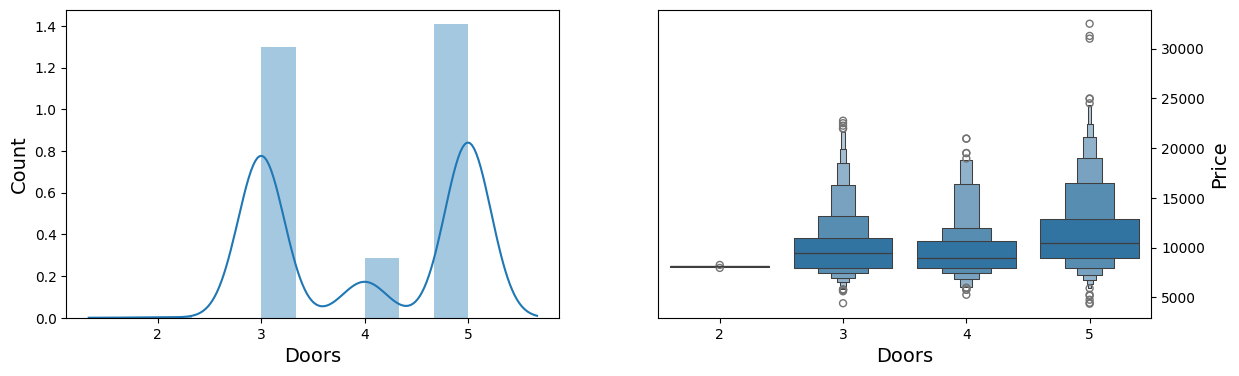

In [98]:
f, axes = plt.subplots(1,2,figsize=(14,4))

sns.distplot(data2['Doors'], ax = axes[0])
axes[0].set_xlabel('Doors', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.boxenplot(x = 'Doors', y = 'Price', data = data2, ax = axes[1])
axes[1].set_xlabel('Doors', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

5 doors car has more price than other doors car.

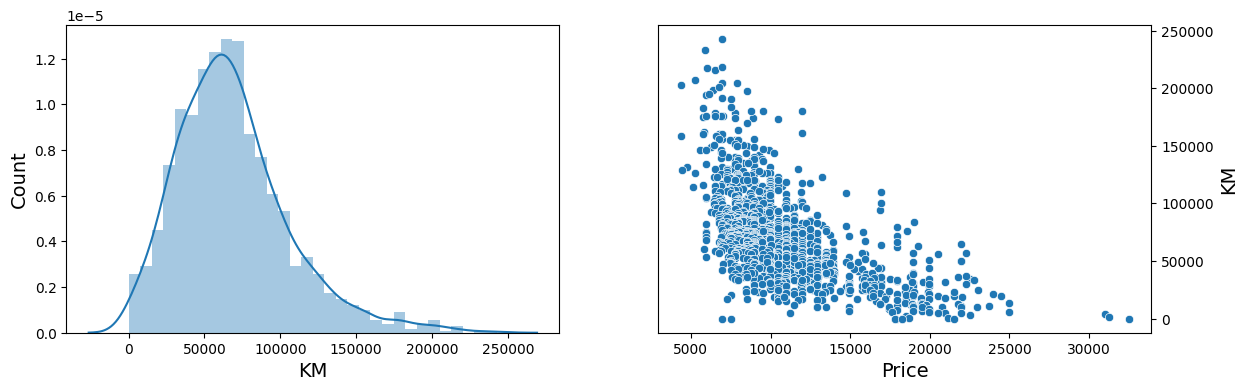

In [99]:
f, axes = plt.subplots(1,2,figsize=(14,4))

sns.distplot(data2['KM'], ax = axes[0])
axes[0].set_xlabel('KM', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.scatterplot(x = 'Price', y = 'KM', data = data2, ax = axes[1])
axes[1].set_xlabel('Price', fontsize=14)
axes[1].set_ylabel('KM', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

Less the Kilometers more the Price, this scenario is seen above.

<Axes: xlabel='Price', ylabel='Age'>

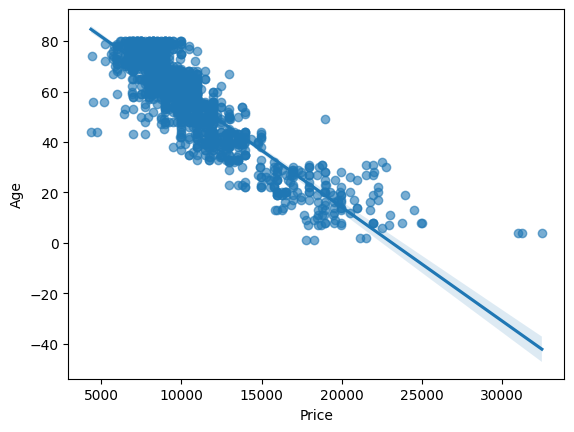

In [104]:
sns.regplot(x = 'Price', y = 'Age', data = data2, scatter_kws={'alpha':0.6})

It is clearly seen here, More Age less Price and Less Age of car More the Price for the car.\
Price is negatively related with Age, KM variables, the line is downward.

**Correlation Matrix**

In [105]:
data2.corr(numeric_only=True)

,Price,Age,KM,HP,Automatic,CC,Doors,QT,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.314134,0.033928,0.124375,0.183604,0.211508,0.063831,0.575869
Age,-0.876273,1.000000,0.504575,-0.155293,0.031354,-0.096549,-0.146929,-0.193319,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,-0.332904,-0.082168,0.103822,-0.035193,0.283312,0.014890,-0.023969
HP,0.314134,-0.155293,-0.332904,1.000000,0.013313,0.035207,0.091803,-0.302287,0.209642,0.087143
Automatic,0.033928,0.031354,-0.082168,0.013313,1.000000,0.066934,-0.027492,-0.055012,-0.098582,0.058499
CC,0.124375,-0.096549,0.103822,0.035207,0.066934,1.000000,0.079254,0.305982,0.014732,0.335077
Doors,0.183604,-0.146929,-0.035193,0.091803,-0.027492,0.079254,1.000000,0.107353,-0.160101,0.301734
QT,0.211508,-0.193319,0.283312,-0.302287,-0.055012,0.305982,0.107353,1.000000,-0.005125,0.621988
Gears,0.063831,-0.005629,0.014890,0.209642,-0.098582,0.014732,-0.160101,-0.005125,1.000000,0.021238
Weight,0.575869,-0.466484,-0.023969,0.087143,0.058499,0.335077,0.301734,0.621988,0.021238,1.000000


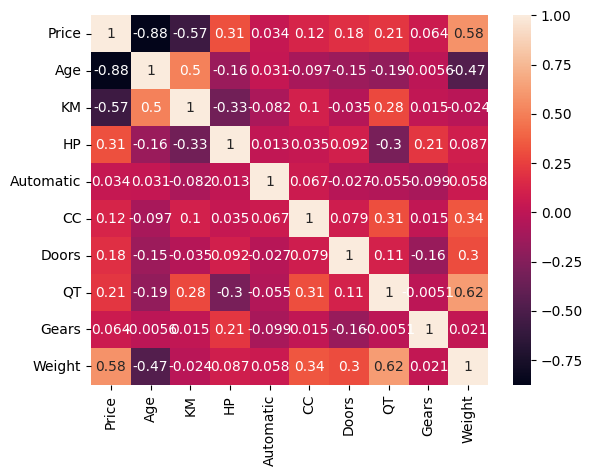

In [106]:
#heatmap for toyota
sns.heatmap(data2.corr(numeric_only= True),annot=True)
plt.show()

Price has moderate relationship with Age,KM,Weight variables (moderate relationship = 0.5 to 0.8)\
Price has weak relationship with HP,CC,Doors,Gears,QT (weak relationship <0.5)

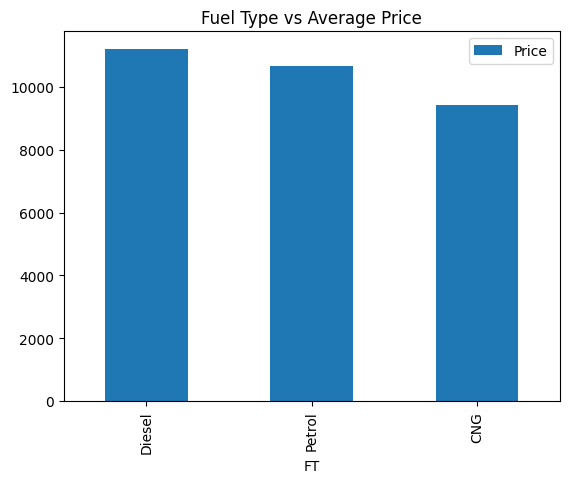

In [108]:
#Correlation between Categorical variable (Fuel Type) with target variable(Price)

df = pd.DataFrame(data2.groupby(['FT'])['Price'].mean().sort_values(ascending = False))
df.plot.bar()
plt.title('Fuel Type vs Average Price')
plt.show()

**Data Preprocessing**

**Converting categorical values to numeric values**  
Dummy Variable is a method in which categorical data is get converted to numerical data (1 and 0) Below, FT(Fuel type) column has three different categorical data Diesel, Petrol and CNG.

In [109]:
# One-hot encoding for Fuel_Type(FT)
data3 = pd.get_dummies(data2,columns=['FT'],dtype=int)
data3.head()

,Price,Age,KM,HP,Automatic,CC,Doors,QT,Gears,Weight,FT_CNG,FT_Diesel,FT_Petrol
0,13500,23,46986,90,0,2000,3,210,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,210,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,210,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,210,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,210,5,1170,0,1,0


### Data Preparation for Model

Machine Learning Task:  
Task is Regression (As target variable is numerical)

**Independent variables** - Age, KM, HP, Automatic, CC, Gears, Doors, QT, Weight, FT_CNG, FT_Petrol, FT_Diesel  
**Target variable** - Price

In [111]:
# Separating Target variable and other independent variables

X = data3.drop('Price', axis = 1).values
y = data3.iloc[:, 0].values.reshape(-1,1)

In [112]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [113]:
print("Shape of X_train: ",X_train.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_test",y_test.shape)

Shape of X_train:  (1076, 12)
Shape of y_train:  (1076, 1)
Shape of X_test:  (359, 12)
Shape of y_test (359, 1)


**Regression Models**

## 1. Multiple Linear Regression

In [115]:
from sklearn.linear_model import LinearRegression
#define the model
regressor_linear = LinearRegression()
#fit the model
regressor_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Cross validation and Model evaluation metrics**

In [116]:
from sklearn.metrics import r2_score, confusion_matrix, accuracy_score, classification_report

# Predicting Cross Validation Score the Test set results
cv_linear = cross_val_score(estimator = regressor_linear, X = X_train, y = y_train, cv = 10)

# Predicting R2 Score the Train set results
y_pred_linear_train = regressor_linear.predict(X_train)
r2_score_linear_train = r2_score(y_train, y_pred_linear_train)

# Predicting R2 Score the Test set results
y_pred_linear = regressor_linear.predict(X_test)
r2_score_linear_test = r2_score(y_test, y_pred_linear)

# Predicting RMSE the Test set results
rmse_linear = (np.sqrt(mean_squared_error(y_test, y_pred_linear)))

print("CV: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)

CV:  0.7361266833583008
R2_score (train):  0.8749549272854531
R2_score (test):  0.8427946133032952
RMSE:  1434.6657561738452


## 2. Decision Tree 

In [117]:
from sklearn.tree import DecisionTreeRegressor
#define the model
regressor_dt = DecisionTreeRegressor(random_state = 0)
# Fitting the Decision Tree Regression Model to the dataset(Train the decision tree regressor)
regressor_dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [118]:
# Predicting Cross Validation Score
cv_dt = cross_val_score(estimator = regressor_dt, X = X_train, y = y_train, cv = 10)

# Predicting R2 Score the Train set results
y_pred_dt_train = regressor_dt.predict(X_train)
r2_score_dt_train = r2_score(y_train, y_pred_dt_train)

# Predicting R2 Score the Test set results
y_pred_dt_test = regressor_dt.predict(X_test)
r2_score_dt_test = r2_score(y_test, y_pred_dt_test)

# Predicting RMSE the Test set results
rmse_dt = (np.sqrt(mean_squared_error(y_test, y_pred_dt_test)))

print('CV: ', cv_dt.mean())
print('R2_score (train): ', r2_score_dt_train)
print('R2_score (test): ', r2_score_dt_test)
print("RMSE: ", rmse_dt)

CV:  0.8238023152574578
R2_score (train):  0.999998568748919
R2_score (test):  0.8602127269782586
RMSE:  1352.8537103323067


## 3. Random Forest

In [119]:
from sklearn.ensemble import RandomForestRegressor
#define the model
regressor_rf = RandomForestRegressor(n_estimators = 1200, random_state = 0)
# Fitting the Random Forest Regression to the dataset
model_rf= regressor_rf.fit(X_train, y_train.ravel())
model_rf

,n_estimators,1200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_scaled = sc_X.fit_transform(X_train)

# Predicting Cross Validation Score
cv_rf = cross_val_score(estimator = regressor_rf, X = X_scaled, y = y_train.ravel(), cv = 10)

# Predicting R2 Score the Train set results
y_pred_rf_train = regressor_rf.predict(X_train)
r2_score_rf_train = r2_score(y_train, y_pred_rf_train)

# Predicting R2 Score the Test set results
y_pred_rf_test = regressor_rf.predict(X_test)
r2_score_rf_test = r2_score(y_test, y_pred_rf_test)

# Predicting RMSE the Test set results
rmse_rf = (np.sqrt(mean_squared_error(y_test, y_pred_rf_test)))

print('CV: ', cv_rf.mean())
print('R2_score (train): ', r2_score_rf_train)
print('R2_score (test): ', r2_score_rf_test)
print("RMSE: ", rmse_rf)

CV:  0.8990576609329078
R2_score (train):  0.987077161560324
R2_score (test):  0.9053359178788076
RMSE:  1113.2934010786016


In [122]:
models = [('Linear Regression', rmse_linear, r2_score_linear_train, r2_score_linear_test, cv_linear.mean()),('Decision Tree Regression', rmse_dt, r2_score_dt_train, r2_score_dt_test, cv_dt.mean()),
          ('Random Forest Regression', rmse_rf, r2_score_rf_train, r2_score_rf_test, cv_rf.mean())   
         ]

In [123]:
compare = pd.DataFrame(data = models, columns=['Model', 'RMSE', 'R2_Score(training)', 'R2_Score(test)', 'Cross-Validation'])
compare

,Model,RMSE,R2_Score(training),R2_Score(test),Cross-Validation
0,Linear Regression,1434.665756,0.874955,0.842795,0.736127
1,Decision Tree Regression,1352.853710,0.999999,0.860213,0.823802
2,Random Forest Regression,1113.293401,0.987077,0.905336,0.899058


The Random Forest model has the lowest RMSE, indicating it makes the most accurate predictions among the models we used. By combining the multiple trees, random forest regression reduces the reliance on any one tree, leading to less overfitting on the training data. Averaging predictions from multiple trees often results in more accurate predictions than a single decision tree.

**Visualizing Models Performance**

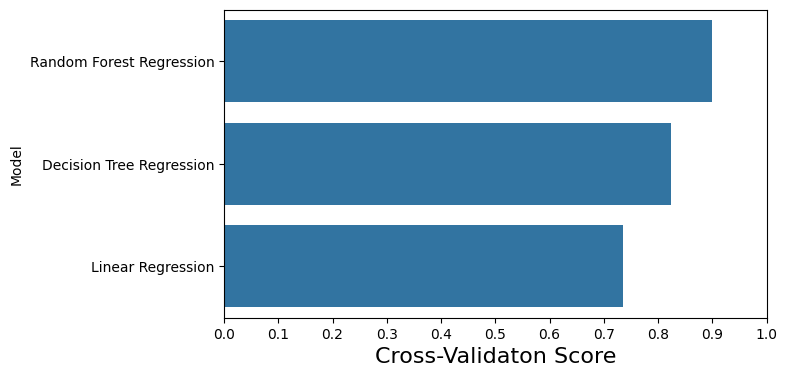

In [125]:
f, axe = plt.subplots(1,1, figsize=(7,4))

compare.sort_values(by=['Cross-Validation'], ascending=False, inplace=True)

sns.barplot(x='Cross-Validation', y='Model', data = compare, ax = axe)
#axes[0].set(xlabel='Region', ylabel='Charges')
axe.set_xlabel('Cross-Validaton Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)
axe.set_xticks(np.arange(0, 1.1, 0.1))
plt.show()

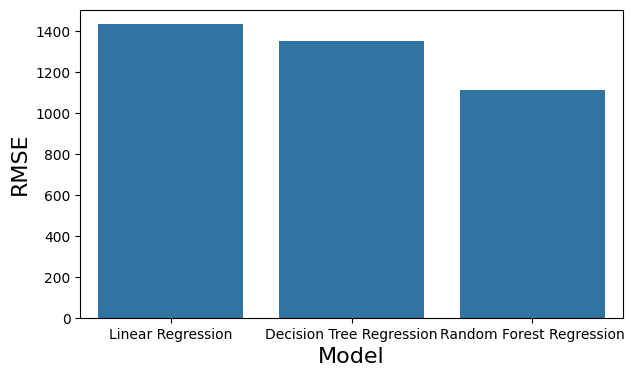

In [126]:
compare.sort_values(by=['RMSE'], ascending=False, inplace=True)

f, axe = plt.subplots(1,1, figsize=(7,4))
sns.barplot(x='Model', y='RMSE', data=compare, ax = axe)
axe.set_xlabel('Model', size=16)
axe.set_ylabel('RMSE', size=16)

plt.show()

From the above results, we can see that Random Forest model gives the best R² value and less RMSE value. Hence this model can be selected as our final model and used for predicting the price.

**Using the model for new data**

In [132]:
#Predict for new data
newdata= {'Age':[20,25,15],'KM':[45678,25972,72438],'FT':["Diesel","Petrol","CNG"],'HP':[90,86,110],'Automatic':[1,0,1],'CC':[2000,1800,1300],'Doors':[3,4,5],'Gears':[5,6,5],'QT':[69,94,210],'Weight':[1025,1100,1250]}

In [134]:
data_pred= pd.DataFrame(newdata,columns=['Age','KM','FT','HP','Automatic','CC','Doors','Gears','QT','Weight'])
data_pred

,Age,KM,FT,HP,Automatic,CC,Doors,Gears,QT,Weight
0,20,45678,Diesel,90,1,2000,3,5,69,1025
1,25,25972,Petrol,86,0,1800,4,6,94,1100
2,15,72438,CNG,110,1,1300,5,5,210,1250


In [135]:
data_pred1 = pd.get_dummies(data_pred,columns=['FT'],dtype=int)
data_pred1.head()

,Age,KM,HP,Automatic,CC,Doors,Gears,QT,Weight,FT_CNG,FT_Diesel,FT_Petrol
0,20,45678,90,1,2000,3,5,69,1025,0,1,0
1,25,25972,86,0,1800,4,6,94,1100,0,0,1
2,15,72438,110,1,1300,5,5,210,1250,1,0,0


In [136]:
new_pred = model_rf.predict(data_pred1)
data_pred1['Pred_Price']=np.round(new_pred,2)
data_pred1

,Age,KM,HP,Automatic,CC,Doors,Gears,QT,Weight,FT_CNG,FT_Diesel,FT_Petrol,Pred_Price
0,20,45678,90,1,2000,3,5,69,1025,0,1,0,15139.80
1,25,25972,86,0,1800,4,6,94,1100,0,0,1,15480.02
2,15,72438,110,1,1300,5,5,210,1250,1,0,0,20196.83
